# Estudio de Caso: Innovaciones de ResNet e Interpretabilidad en Redes Neuronales Convolucionales

## 1. La Súper Carretera de los Gradientes: Solución al Problema del Gradiente Desvanecido

El entrenamiento de redes neuronales convolucionales (CNNs) profundas enfrenta un obstáculo fundamental conocido como el *problema del gradiente desvanecido* (*vanishing gradient problem*). Durante la retropropagación, los gradientes se multiplican sucesivamente a través de cada capa; cuando dichos factores son menores a uno, el producto resultante decrece exponencialmente conforme aumenta la profundidad de la red. En consecuencia, las capas iniciales reciben señales de actualización prácticamente nulas, lo que impide su aprendizaje efectivo y provoca que redes más profundas exhiban un rendimiento paradójicamente inferior al de sus contrapartes menos profundas (He et al., 2016).

La arquitectura ResNet (*Residual Network*), propuesta por He, Zhang, Ren y Sun en 2015, aborda este problema mediante la introducción de **conexiones de salto** (*skip connections*). En lugar de requerir que cada bloque de capas aprenda directamente la transformación deseada, estos módulos residuales permiten que la entrada *x* fluya sin modificación hacia la salida del bloque, sumándose al resultado de las capas intermedias. Desde la perspectiva del flujo de gradientes, las conexiones de salto crean una **"súper carretera"**: un camino directo que garantiza que el gradiente pueda propagarse sin atenuación desde las capas finales hasta las iniciales. De este modo, incluso en redes de más de cien capas, cada parámetro recibe una señal de aprendizaje suficiente, y el problema de degradación queda resuelto.



In [1]:
# Ejemplo de implementación de un Bloque Residual Básico en PyTorch
import torch
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        # Primera convolución
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        # Segunda convolución
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Conexión de salto (Skip connection)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x) # Guardamos la entrada para la conexión de salto

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # ¡La súper carretera! Sumamos la identidad
        out += identity
        out = self.relu(out)

        return out

# Creamos una instancia del bloque y pasamos un tensor de prueba
block = BasicBlock(64, 64)
x = torch.randn(1, 64, 32, 32)
output = block(x)
print(f"Forma de entrada: {x.shape}")
print(f"Forma de salida:  {output.shape}")


Forma de entrada: torch.Size([1, 64, 32, 32])
Forma de salida:  torch.Size([1, 64, 32, 32])


## 2. Eficiencia del Aprendizaje Residual y Convoluciones Bottleneck

El principio central de ResNet es el **Aprendizaje Residual**. En lugar de modelar la función completa H(x), cada bloque aprende únicamente la función residual F(x) = H(x) − x, de manera que la salida del bloque se expresa como H(x) = F(x) + x. Esta reformulación simplifica la optimización: si la transformación identidad fuese óptima, bastaría con que F(x) convergiera a cero, tarea considerablemente más sencilla que aprender la identidad desde cero mediante capas no lineales apiladas.

Para escalar esta idea a redes extremadamente profundas —como ResNet-152— sin un costo computacional prohibitivo, se emplean **bloques bottleneck**. Estos bloques utilizan convoluciones de **1×1** que reducen la dimensionalidad del mapa de características antes de aplicar la convolución espacial de 3×3, y la restauran después. Esta estrategia, compartida con arquitecturas como Inception (Szegedy et al., 2015), logra una reducción significativa del número de parámetros y operaciones, manteniendo la capacidad expresiva de la red. Gracias a esta combinación de aprendizaje residual y bottlenecks, ResNet alcanzó un error top-5 del 3.57 % en ImageNet, superando por primera vez el rendimiento de nivel humano estimado en aproximadamente un 5 %.



In [2]:
# Ejemplo de implementación de un Bloque Bottleneck
class BottleneckBlock(nn.Module):
    expansion = 4 # El canal de salida es 4 veces el canal interno

    def __init__(self, in_channels, out_channels, stride=1):
        super(BottleneckBlock, self).__init__()

        # 1x1 Convolución (Reduce la dimensión)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3 Convolución espacial
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 Convolución (Restaura/Expande la dimensión)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out += identity
        out = self.relu(out)

        return out

bottleneck = BottleneckBlock(in_channels=256, out_channels=64)
x_bottle = torch.randn(1, 256, 32, 32)
out_bottle = bottleneck(x_bottle)
print(f"Entrada Bottleneck: {x_bottle.shape}")
print(f"Salida Bottleneck:  {out_bottle.shape}")


Entrada Bottleneck: torch.Size([1, 256, 32, 32])
Salida Bottleneck:  torch.Size([1, 256, 32, 32])


## 3. Confirmación de la Jerarquía de Representación mediante Visualización

Las técnicas de visualización basadas en gradiente, como los **mapas de saliencia** (*Saliency Maps*) y la **generación de imágenes de fantasía** (*DeepDream*, *feature visualization*), permiten inspeccionar qué regiones y patrones activan las neuronas de cada capa. Los mapas de saliencia calculan la derivada parcial de la salida de la red respecto a cada píxel de la imagen de entrada, revelando las regiones más influyentes en la decisión del modelo. Estas técnicas confirman la **naturaleza jerárquica** de la representación interna: las capas tempranas responden a rasgos primitivos —bordes, texturas y contrastes—, mientras que las capas profundas codifican combinaciones complejas —ojos, rostros, partes de objetos—, en consonancia con la organización de la corteza visual biológica descrita por Hubel y Wiesel (1962).


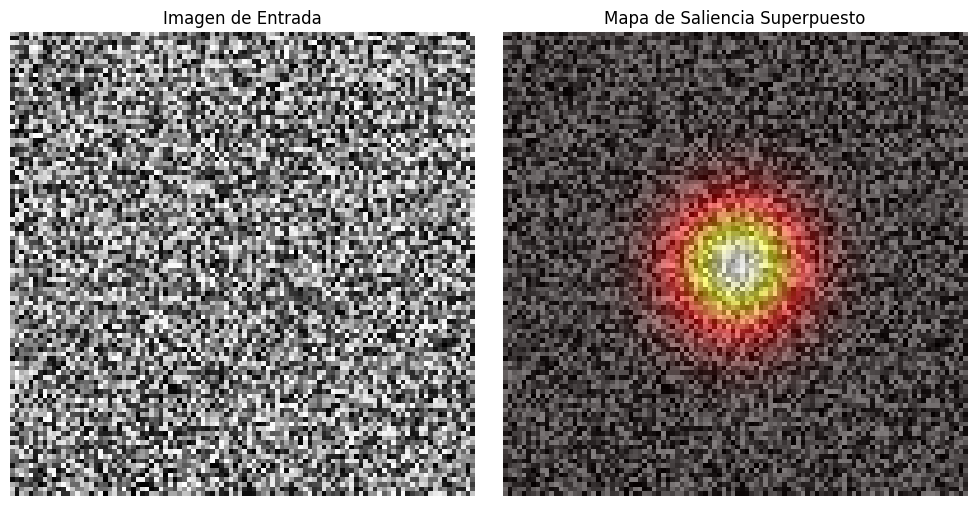

In [3]:
# Visualización simulada de un Mapa de Saliencia
import matplotlib.pyplot as plt
import numpy as np

# Simulamos una imagen original y un mapa de saliencia
img_original = np.random.rand(100, 100)
saliency_map = np.exp(-((np.arange(100)-50)**2 + (np.arange(100)[:,None]-50)**2)/200)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Imagen de Entrada')
axes[0].axis('off')

# Mostramos el mapa de saliencia superpuesto
axes[1].imshow(img_original, cmap='gray')
axes[1].imshow(saliency_map, cmap='hot', alpha=0.5)
axes[1].set_title('Mapa de Saliencia Superpuesto')
axes[1].axis('off')

plt.tight_layout()
plt.show()


La imagen izquierda muestra ruido aleatorio simulando una entrada. A la derecha, el "mapa de saliencia" revela un centro brillante (amarillo/rojo). Estos colores brillantes indican matemáticamente las áreas específicas donde la red neuronal concentra su atención para tomar una decisión. Ayuda a entender y justificar cómo "piensan" los modelos.

## 4. Convergencia Interdisciplinaria

La arquitectura de las CNNs encuentra su justificación en la convergencia entre principios matemáticos e inspiración biológica. La **compartición de pesos** y la **equivarianza traslacional** de las convoluciones reflejan formalmente la propiedad de los campos receptivos neuronales de detectar el mismo patrón independientemente de su posición espacial. Así, ResNet e Inception no solo constituyen logros de ingeniería, sino que también validan un modelo computacional coherente con los mecanismos de la percepción visual biológica, consolidando el vínculo entre neurociencia y aprendizaje profundo.

---

**Referencias**

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual Learning for Image Recognition. *CVPR*.
- Hubel, D. H., & Wiesel, T. N. (1962). Receptive fields, binocular interaction and functional architecture in the cat's striate cortex. *The Journal of Physiology*, 160(1), 106–154.
- Szegedy, C., et al. (2015). Going Deeper with Convolutions. *CVPR*.
- Simonyan, K., Vedaldi, A., & Zisserman, A. (2014). Deep Inside Convolutional Networks: Visualising Image Classification Models and Saliency Maps. *ICLR Workshop*.
